<https://drive.google.com/file/d/14HxGsihuTglSbjmhCMANv5f9o6SKR5OC/view>

### importing standard libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load the data

In [3]:
df = pd.read_csv("./Dataset/employe.csv")

### exploring the data

In [4]:
# print top rows

df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [5]:
df.tail()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low
14998,0.77,0.83,6,271,3,0,0,0,support,low


In [6]:
df.sample(10)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
3181,0.59,0.62,3,203,4,0,0,0,support,medium
13169,0.63,0.55,4,200,3,1,0,0,RandD,low
4733,0.71,0.99,5,208,2,1,0,0,accounting,low
12635,0.48,0.67,4,220,3,0,0,1,management,medium
12741,0.91,0.97,4,183,3,0,0,0,support,low
7745,0.94,0.90,4,144,4,0,0,0,support,low
11928,0.66,0.81,3,174,3,0,0,0,technical,low
897,0.73,0.95,4,223,6,0,1,0,support,low
631,0.61,0.86,4,196,4,0,1,0,hr,low
9416,0.80,0.93,3,225,4,0,0,0,product_mng,low


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [8]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='str')

In [9]:
df.shape

(14999, 10)

### Data processing

In [10]:
df.isnull().sum()

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(3008)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(11991, 10)

In [15]:
# rename a column

df = df.rename(columns = {"timeSpent.company":"timeSpent"})

### Data Analysis

In [16]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='str')

In [17]:
df['numberOfProjects'].value_counts()

numberOfProjects
4    3685
3    3520
5    2233
2    1582
6     826
7     145
Name: count, dtype: int64

### 1. Find out how many departments are there in the company and how many employees work in each departement.

In [18]:
df['dept'].value_counts()

dept
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

In [19]:
dept = df['dept'].unique()
print(np.array)

<built-in function array>


### 2. How many employees are distributed in different salary ranges?

In [20]:
df['salary'].value_counts()

salary
low       5740
medium    5261
high       990
Name: count, dtype: int64

<Axes: xlabel='salary', ylabel='count'>

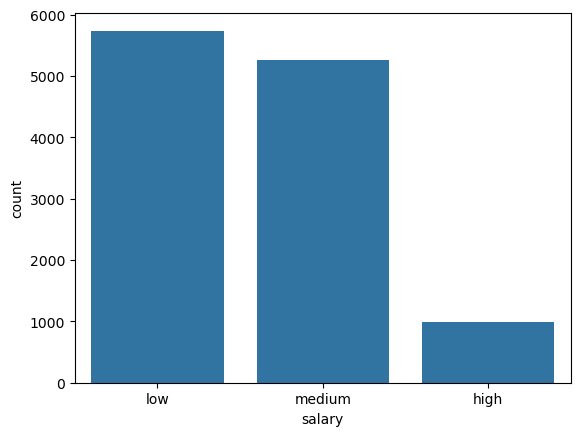

In [21]:
sns.countplot(data=df, x='salary')

### 3. Create a chart which shows the relationship between number of projects an employee is handling and if they left or not

In [22]:
df['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

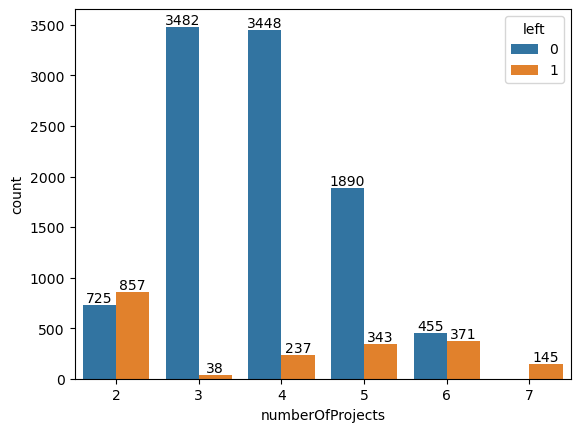

In [23]:
x1 = sns.countplot(data = df, x='numberOfProjects', hue = 'left')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.show()

- Employee having 2 projects tend to leave they might be feeling underutilized or bored.-- it's a possibility that they are just newbies.

### 4. Check out the relationship between promotion and employee turnover.

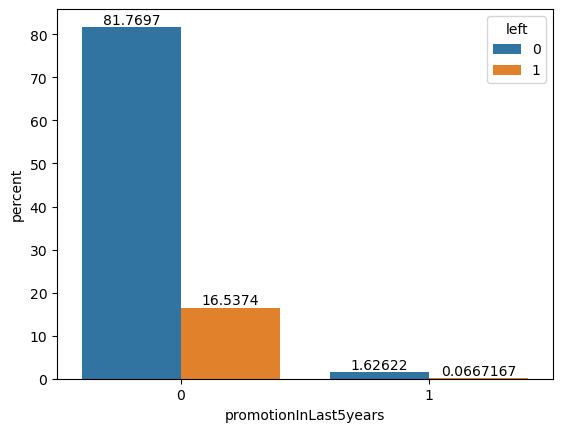

In [24]:
x1 = sns.countplot(data= df, x = 'promotionInLast5years', hue = 'left', stat ='percent')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.show()

### 5. Find out the relationship between tenure and employee turnover.

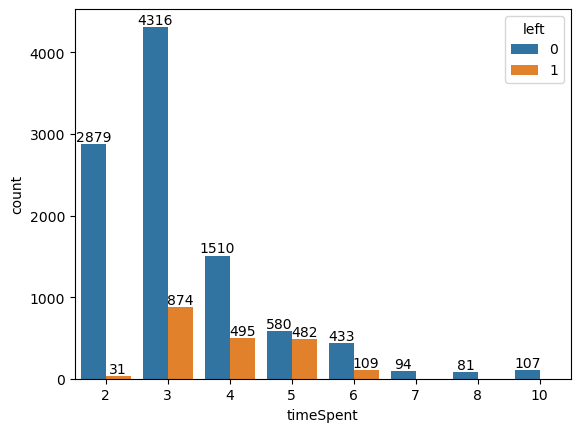

In [27]:
x1 = sns.countplot(data= df, x = 'timeSpent', hue = 'left')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.show()

### Filter the employees who have got the promotion

In [28]:
promoted_emp = df[df['promotionInLast5years'] == 1]

In [29]:
promoted_emp

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent,workAccident,left,promotionInLast5years,dept,salary
52,0.79,0.59,4,139,3,0,1,1,management,low
189,0.11,0.79,6,292,4,0,1,1,technical,low
386,0.41,0.56,2,154,3,0,1,1,support,medium
1131,0.44,0.55,2,128,3,0,1,1,IT,medium
2996,0.94,0.80,5,111,4,0,0,1,RandD,medium
...,...,...,...,...,...,...,...,...,...,...
13929,0.55,0.40,3,139,8,0,0,1,hr,medium
14388,0.53,0.74,5,237,2,0,0,1,support,medium
14488,0.85,0.57,4,150,3,0,0,1,sales,high
14530,0.87,1.00,4,258,5,1,1,1,sales,medium


In [30]:
promoted_but_left = df[(df['promotionInLast5years']== 1) & (df['left']==1)]

In [31]:
promoted_but_left

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent,workAccident,left,promotionInLast5years,dept,salary
52,0.79,0.59,4,139,3,0,1,1,management,low
189,0.11,0.79,6,292,4,0,1,1,technical,low
386,0.41,0.56,2,154,3,0,1,1,support,medium
1131,0.44,0.55,2,128,3,0,1,1,IT,medium
7980,0.45,0.51,2,160,3,1,1,1,sales,low
8085,0.41,0.46,2,160,3,0,1,1,sales,low
8469,0.46,0.45,2,138,3,0,1,1,IT,low
14530,0.87,1.00,4,258,5,1,1,1,sales,medium


### Create a chart to see the relationship between satisfactory level, no of projects, avgMonthlyHours

<Axes: xlabel='satisfactoryLevel', ylabel='avgMonthlyHours'>

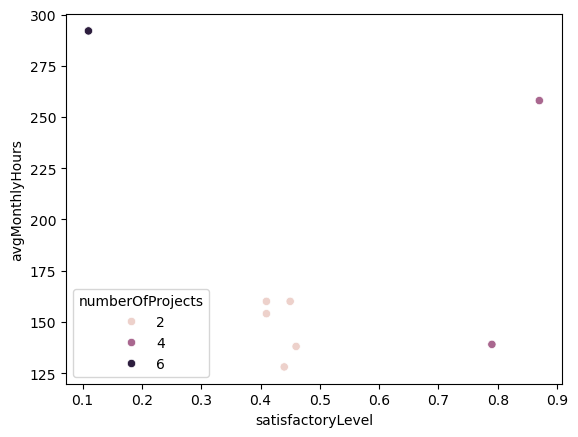

In [32]:
sns.scatterplot(data =promoted_but_left, x = 'satisfactoryLevel', y = 'avgMonthlyHours', hue = 'numberOfProjects')

In [33]:
# 1. satisfactory level data distribution
# 2. create a chart which shows the salary distribution and accordingly the attrition
# 3. sns.heatmap

# create the charts and put them all together using subplots

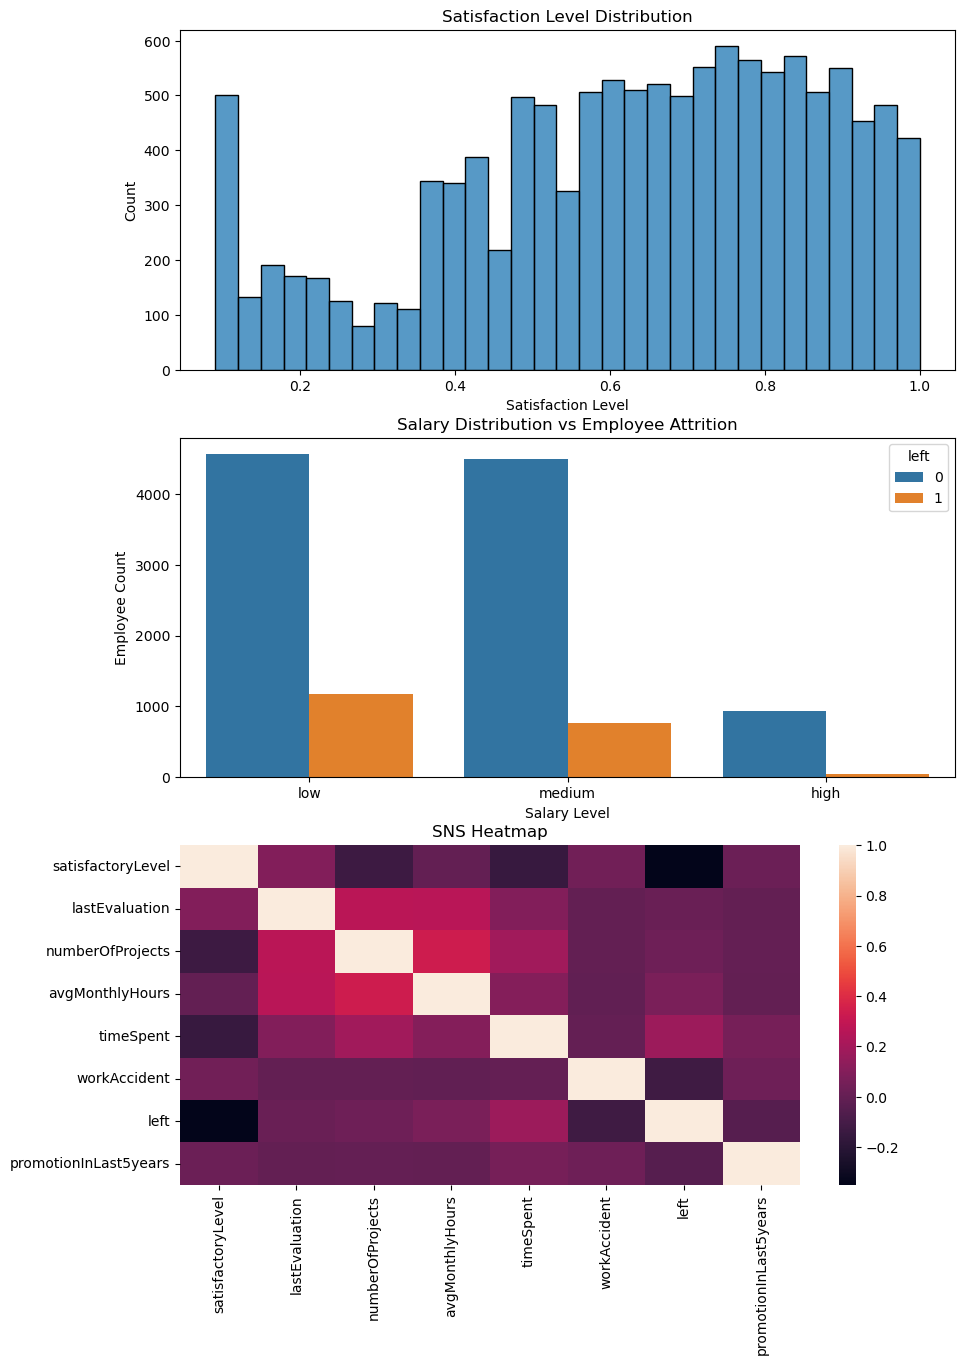

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize = (10,15))

plt.subplot(3,1,1)
sns.histplot(data = df, x= 'satisfactoryLevel')
plt.title("Satisfaction Level Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")

plt.subplot(3,1,2)
sns.countplot(x='salary', hue='left', data=df)
plt.title('Salary Distribution vs Employee Attrition')
plt.xlabel('Salary Level')
plt.ylabel('Employee Count')

plt.subplot(3,1,3)
sns.heatmap(df.corr(numeric_only=True))
plt.title("SNS Heatmap")
plt.show()

plt.tight_layout()

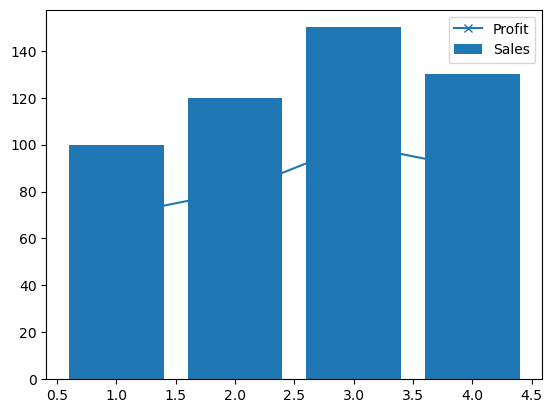

In [35]:
months = [1,2,3,4]
sales = [100, 120, 150, 130]
profit = [70, 80, 100, 90]

plt.bar(months, sales, label ='Sales')

plt.plot(months, profit, marker='x', label = 'Profit')

plt.legend()

plt.show()

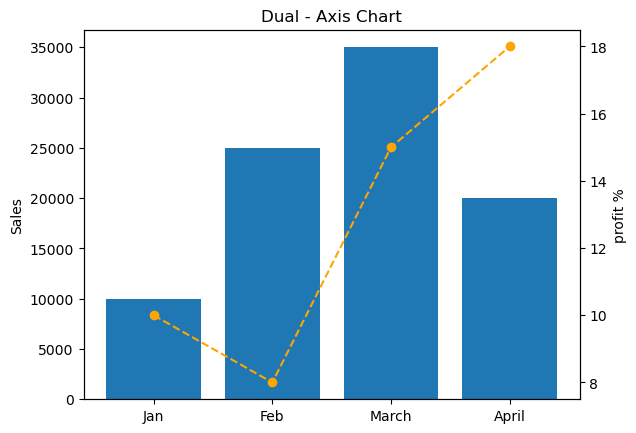

In [37]:
months = ['Jan', "Feb", "March", "April"]
sales = [10000, 25000, 35000, 20000 ]
profit = [10, 8, 15, 18]

fig, ax1 = plt.subplots()

ax1.bar(months, sales, label = 'Sales')
ax1.set_ylabel("Sales")

ax2 = ax1.twinx()

ax2.plot(months, profit, marker = 'o', linestyle = '--', color = 'orange', label = 'Sales')
ax2.set_ylabel("profit %")

plt.title("Dual - Axis Chart")
plt.show()